In [2]:
import pandas as pd
import numpy as np
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))
rfm = pd.read_sql("SELECT * FROM rfm_base", engine)

# Postgres returns recency as an interval -> pandas timedelta. Convert to plain days.
if pd.api.types.is_timedelta64_dtype(rfm["recency"]):
    rfm["recency"] = rfm["recency"].dt.days

# Keep 1-5 scores ONLY for later human-readable labeling -- never for clustering
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

# Clustering input: raw values, log-transformed (frequency/monetary are heavily
# right-skewed -- a handful of big spenders otherwise dominate the distance metric),
# then standardized
X_raw = rfm[["recency", "frequency", "monetary"]].copy()
X_raw["frequency"] = np.log1p(X_raw["frequency"])
X_raw["monetary"] = np.log1p(X_raw["monetary"])
X_scaled = StandardScaler().fit_transform(X_raw)

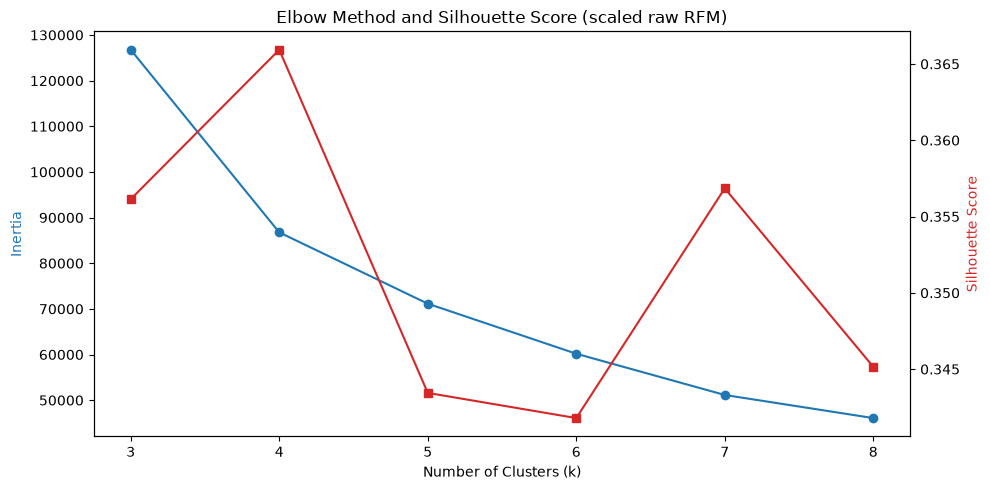

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias, sil_scores = [], []
k_values = range(3, 9)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Number of Clusters (k)'); ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(k_values, inertias, marker='o', color='tab:blue')
ax2 = ax1.twinx(); ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_values, sil_scores, marker='s', color='tab:red')
plt.title('Elbow Method and Silhouette Score (scaled raw RFM)')
fig.tight_layout(); plt.show()

In [4]:
import numpy as np

for k in [3, 4, 7]:
    scores = []
    for seed in [0, 1, 2, 3, 4]:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X_scaled)
        scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}: mean={np.mean(scores):.4f}, std={np.std(scores):.4f}")

k=3: mean=0.3561, std=0.0001
k=4: mean=0.3659, std=0.0000
k=7: mean=0.3568, std=0.0000


In [5]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
rfm["cluster"] = km4.labels_
print(rfm.cluster.value_counts())

cluster
0    32400
3    31021
1    27136
2     2801
Name: count, dtype: int64


In [6]:
from scipy.stats import kruskal

CHOSEN_K = 4

final_km = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10).fit(X_scaled)
rfm["cluster"] = final_km.labels_

groups = [rfm[rfm.cluster == s]["monetary"] for s in rfm.cluster.unique()]
H, p = kruskal(*groups)
n, k = len(rfm), rfm.cluster.nunique()
epsilon_sq = (H - k + 1) / (n - k)

print(f"H={H:.2f}, p{'<.001' if p < .001 else f'={p:.4f}'}, epsilon-squared={epsilon_sq:.4f}")

H=54655.04, p<.001, epsilon-squared=0.5854


In [12]:
cluster_summary = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].median()
print(cluster_summary)

# Must have exactly CHOSEN_K entries, matched to what cluster_summary actually shows
segment_names = {
    2: "Champions",           # freq=2.0 (only repeat-buyer group), highest monetary, decent recency
    0: "Recent Customers",    # best recency (206 days), single purchase, moderate spend
    3: "Price-Sensitive New", # similarly recent, but lowest monetary by far ($43.80)
    1: "Hibernating"          # worst recency by a wide margin (468 days), single purchase
}
rfm["segment"] = rfm["cluster"].map(segment_names)

rfm.segment.value_counts()

         recency  frequency  monetary
cluster                              
0          206.0        1.0    159.00
1          468.0        1.0     81.99
2          247.0        2.0    182.10
3          204.0        1.0     43.80


segment
Recent Customers       32400
Price-Sensitive New    31021
Hibernating            27136
Champions               2801
Name: count, dtype: int64

In [13]:
final_segments = rfm[["customer_unique_id", "segment", "recency", "frequency", "monetary"]]
final_segments.to_sql("customer_segments", engine, if_exists="replace", index=False)
print("Phase 4 complete (corrected).")

Phase 4 complete (corrected).
